In [43]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.datasets import make_moons
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline

In [9]:
X, y = make_moons(noise=.15, random_state=37)

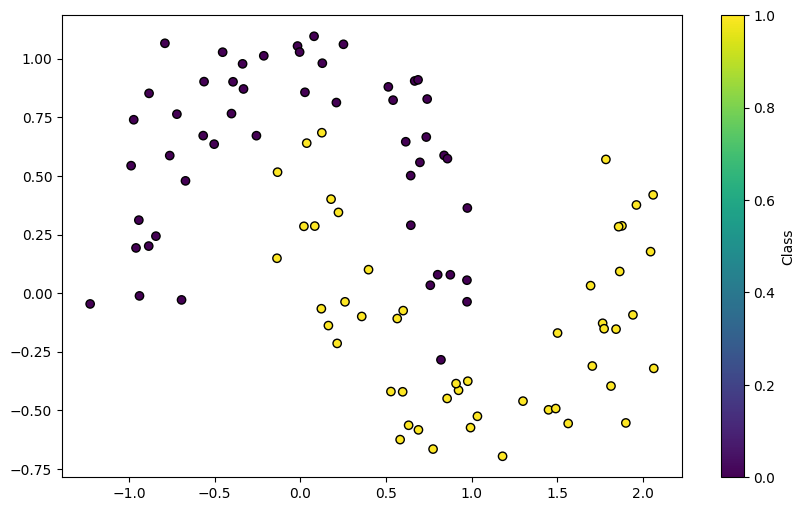

In [10]:
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
plt.colorbar(label='Class')
plt.show()

In [29]:
st_scaler = StandardScaler()
X_st = st_scaler.fit_transform(X)

mm_scaler = MinMaxScaler()
X_mm = mm_scaler.fit_transform(X)

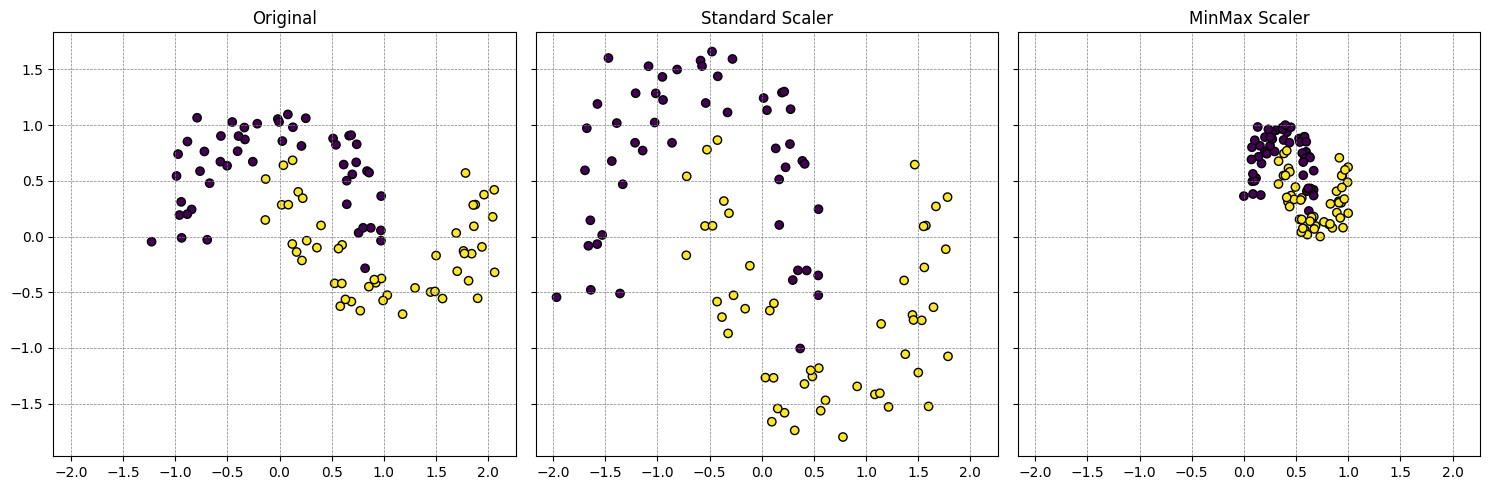

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

axes[0].scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
axes[0].set_title('Original')

axes[1].scatter(X_st[:, 0], X_st[:, 1], c=y, edgecolors='k')
axes[1].set_title('Standard Scaler')

axes[2].scatter(X_mm[:, 0], X_mm[:, 1], c=y, edgecolors='k')
axes[2].set_title('MinMax Scaler')

for ax in axes:
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray')

plt.tight_layout()
plt.show()

In [81]:
def plot_decision_boundary(model, X, y, title='Decision Boundary', ax=None):
    h = .02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = np.reshape(Z, xx.shape)
    if ax is None:
        print('here')
        fig, ax = plt.subplots(figsize=(10, 6))
    ax.contourf(xx, yy, Z, alpha=0.3)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
    ax.set_title(title)


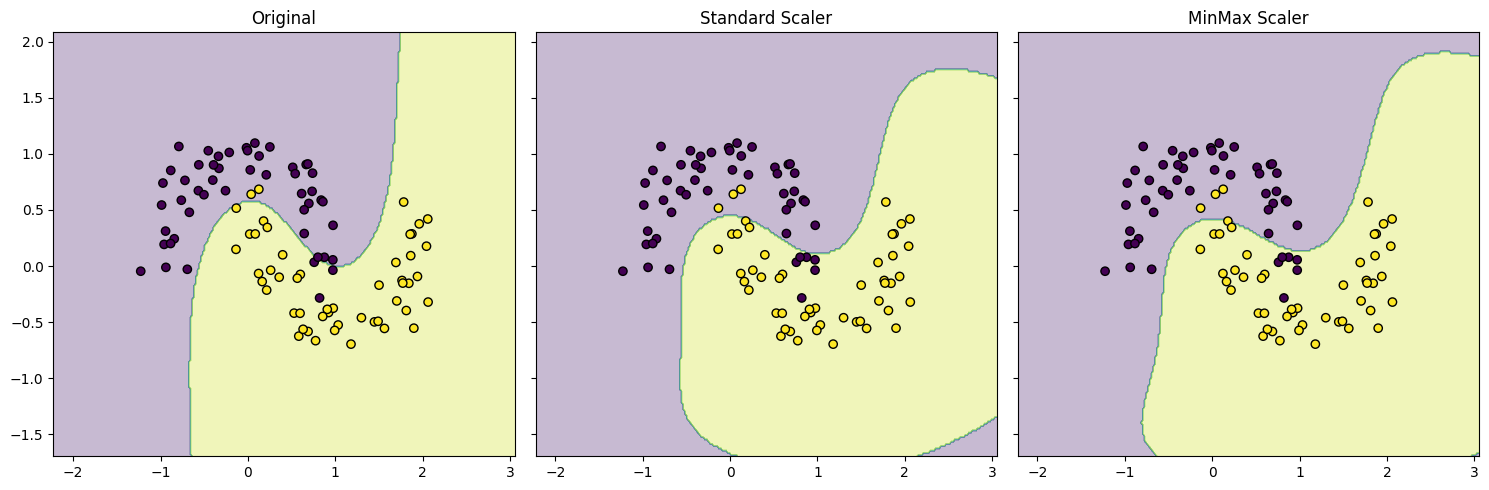

In [82]:
rbf_svm = SVC(kernel='rbf', C=1.0)
rbf_svm.fit(X, y)

rbf_st = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=1.0))
rbf_st.fit(X, y)

rbf_mm = make_pipeline(MinMaxScaler(), SVC(kernel='rbf', C=1.0))
rbf_mm.fit(X, y)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

plot_decision_boundary(rbf_svm, X[:], y[:], title='Original', ax=axes[0])
plot_decision_boundary(rbf_st, X[:], y[:], title='Standard Scaler', ax=axes[1])
plot_decision_boundary(rbf_mm, X[:], y[:], title='MinMax Scaler', ax=axes[2])

plt.tight_layout()
plt.show()